<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
Artificial Intelligence <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Spring 2025<br>
<font color=3C99D size=5>
Practical Assignment 1 - Search <br>
<font color=696880 size=4>
Amir Homayoon sharifi zade

____________

In [67]:
#insert your information
NAME = 'Zeynab Ashouri'
STUDENT_NUMBER = '401103882'

# Libraries

In [68]:
import random
import heapq
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
import time
from itertools import combinations

# **Uninformed Search**

In this part you are going to implement the famous algorithms of graph search on some random graph.
At first you will implement DFS, after that BFS will be implemented and finally you'll implement some heuristic and preform A*.
Here are some helper functions to generate and plot the graph. Do not touch the code in the below cells and only complete the parts with a TODO hashtag.

In [89]:
# Create a random graph with blocked edges (None means blocked)
def generate_random_graph(n, edge_probability=0.1, max_weight=10):
    graph = {i: {} for i in range(n)}
    for node in range(n):
        for neighbor in range(node + 1, n):
            if random.random() < edge_probability:  # Edge exists with given probability
                weight = random.randint(1, max_weight)
                graph[node][neighbor] = weight
                graph[neighbor][node] = weight
    return graph

In [90]:
def plot_graph(graph, path=None, explored=None):
    # Create a fixed layout using networkx's spring layout (force-directed)
    G = nx.Graph(graph)

    # Fixed layout (positions determined from the graph)
    pos = nx.spring_layout(G, seed=42)  # Ensures the same layout every time

    # Draw edges
    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='gray', width=1.5)  # Draw all edges in gray

    # Draw nodes (default color for non-explored and non-path nodes)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightgreen', label="Nodes")

    # Highlight the explored nodes
    if explored:
        nx.draw_networkx_nodes(G, pos, nodelist=explored, node_size=300, node_color='blue', label="Explored")

    # Highlight the path nodes
    if path:
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=300, node_color='red', label="Path")

    # Add labels for the nodes
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', font_color='black')

    # Add the legend
    ax.legend()

    ax.set_title("Graph Visualization")
    plt.axis('off')  # Turn off the axis for a cleaner visualization
    plt.show()


# DFS

In [91]:
def dfs(graph, start, goal):
    #TODO: implement DFS search
    visited_nodes = [(start, [start])]
    explored = set()

    while visited_nodes:
        (node, path) = visited_nodes.pop() 

        if node not in explored:
            if node == goal:
                return list(path), list(explored)

            explored.add(node)

            for adjacent in graph[node]:
                if adjacent not in explored:
                    visited_nodes.append((adjacent, path + [adjacent]))

    #return the "path" which is a list of nodes in path and the "explored" which is list of nodes who are explored
    return None, list(explored)


# BFS

In [92]:
def bfs(graph, start, goal):
    #TODO: implement BFS search
    visited_nodes = deque([(start, [start])]) 
    explored = set()

    while visited_nodes:
        (node, path) = visited_nodes.popleft() 

        if node not in explored:
            if node == goal:
               return list(path), list(explored)

            explored.add(node) 

            for adjacent in graph[node]:
                if adjacent not in explored:
                    visited_nodes.append((adjacent, path + [adjacent]))
    #return the "path" which is a list of nodes in path and the "explored" which is list of nodes who are explored
    return None, list(explored)


**So far, we have explored two uninformed search methods: DFS, BFS. Briefly explain the advantages and disadvantages of each method in the context of the Maze Problem and compare their performance based on your observations (consider both time and memory).**

Your Answer:

We know that the BFS algorithm is complete (if b is finite) and also, when the cost of each edge is 1 as in this case, BFS is optimal. Moreover, it is generally understood that the time and space complexity of BFS are on the order of O(b^(d+1)). The DFS algorithm might encounter repeated states in a tree search and fall into a loop (although here we are performing a graph search, so that does not occur), so DFS may not be complete and therefore is not necessarily optimal. Additionally, it is generally known that the time complexity of DFS is on the order of O(b^m), which becomes enormous when m is much larger than d, though if the solution is dense it is faster than BFS. The space complexity is on the order of O(bm).

In summary, the advantage of BFS is that it is complete, optimal, and has a better running time, whereas DFS requires much less space (linear), which is far superior to exponential memory usage. practical observations, after executing both algorithms several times, confirm the theoretical findings and show that BFS has a better execution time and DFS uses less space.

# A star


In [ ]:
# Define heuristic functions
# A* Search (using simple heuristics: Manhattan distance or random)
def manhattan_distance(a, b, pos):
    x1, y1 = pos[a]
    x2, y2 = pos[b]
    return abs(x1 - x2) + abs(y1 - y2)
    
# Random heuristic
def random_heuristic(a, b, pos):
    return random.randint(1, 10)  # Random heuristic for demonstration

def a_star(graph, start, goal, heuristic, pos):
    #TODO: implement A* search

    visited_nodes = []
    heapq.heappush(visited_nodes, (0, start))

    g_score = {}
    f_score = {}
    for node in graph:
        g_score[node] = float('inf')
        f_score[node] = float('inf')

    g_score[start] = 0
    f_score[start] = heuristic(start, goal, pos)
    
    previous_nodes = {}
    for node in graph:
        previous_nodes[node] = None

    explored = set()
    
    while visited_nodes:
        current_f_score, current_node = heapq.heappop(visited_nodes)

        if current_node in explored:
            continue
        
        if current_node == goal:
            path = deque()
            while current_node is not None:
                path.appendleft(current_node)
                current_node = previous_nodes[current_node]
            return list(path), list(explored)

        explored.add(current_node)
        
        for adjacent in graph[current_node]:
            new_g_score = g_score[current_node] +  graph[current_node][adjacent]
            
            if new_g_score < g_score[adjacent]:
                previous_nodes[adjacent] = current_node
                g_score[adjacent] = new_g_score
                f_score[adjacent] = g_score[adjacent] + heuristic(adjacent, goal, pos)
                
                if adjacent not in explored:
                    heapq.heappush(visited_nodes, (f_score[adjacent], adjacent))
    

    return None, list(explored)


# Results

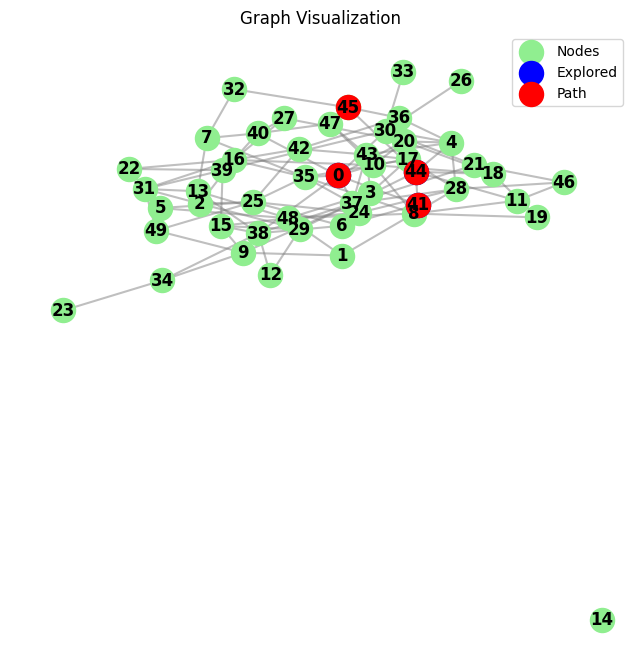

DFS Path: [0, 41, 44, 45]


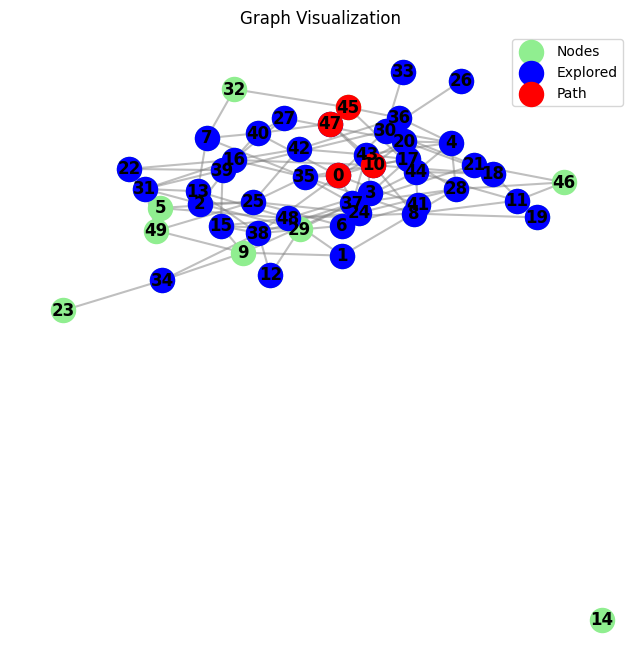

BFS Path: [0, 10, 47, 45]


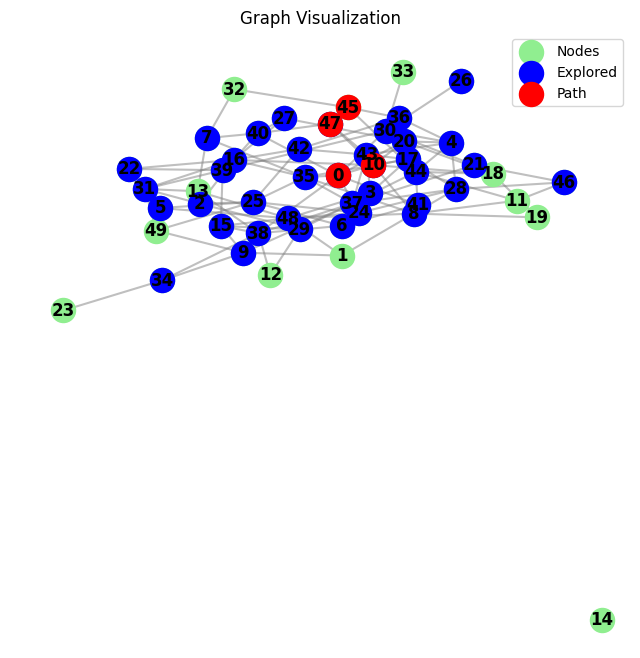

A* Path with Random Heuristic: [0, 10, 47, 45]


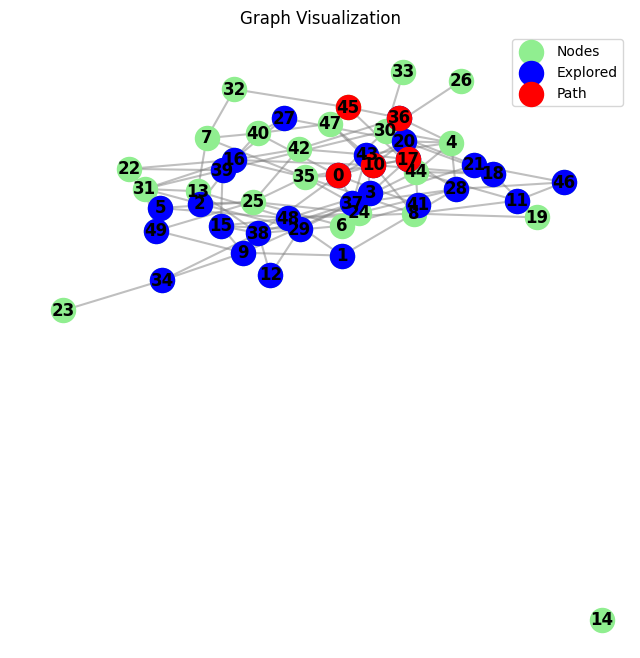

A* Path with Manhattan Distance Heuristic: [0, 10, 17, 36, 45]


In [109]:
# Parameters
num_nodes = 50  # Number of nodes in the graph
start_node = 0  # Starting node
goal_node = 45   # Goal node

# Generate random graph
random_graph = generate_random_graph(num_nodes)

# # Get random node positions for Manhattan distance calculation
positions = {i: (random.randint(0, 100), random.randint(0, 100)) for i in range(num_nodes)}

# Run DFS
path_dfs, explored_dfs = dfs(random_graph, start_node, goal_node)
plot_graph(random_graph, path=path_dfs, explored=explored_dfs)
print(f"DFS Path: {path_dfs}")

# Run BFS
path_bfs, explored_bfs = bfs(random_graph, start_node, goal_node)
plot_graph(random_graph, path=path_bfs, explored=explored_bfs)
print(f"BFS Path: {path_bfs}")

# Run A* with Random Heuristic in same manner as above
path_a_star_random, explored_a_star_random = a_star(random_graph, start_node, goal_node, random_heuristic,positions)
plot_graph(random_graph, path=path_a_star_random, explored=explored_a_star_random)
print(f"A* Path with Random Heuristic: {path_a_star_random}")

# Run A* with Manhattan Distance Heuristic
path_a_star_manhattan, explored_a_star_manhattan = a_star(random_graph, start_node, goal_node, manhattan_distance ,positions)
plot_graph(random_graph, path=path_a_star_manhattan, explored=explored_a_star_manhattan)
print(f"A* Path with Manhattan Distance Heuristic: {path_a_star_manhattan}")


**Explain your heuristic and observation's result. Also, compare the A\* method with Uninformed search in the context of the problem.**

In this problem, for example, vertex 0 might be at position (0,0) and vertex 45 at (100,100), and there may be an edge directly connecting these two vertices. In this case, the cost of traveling from vertex 0 to vertex 45 is at most the weight of this edge, but the Manhattan distance between the two vertices is 200. This clearly shows that the Manhattan heuristic in this case is neither admissible nor consistent.

The Manhattan heuristic only becomes admissible if the edges of the graph are weighted such that the weight of each edge is at least the Manhattan distance between its endpoints. However, in the general case of our problem, this condition does not hold.

The random heuristic has no relation to the structure of the graph or the positions of the vertices, and therefore, the search becomes extremely inefficient because the choice of which vertex to expand is almost random. This heuristic is neither admissible nor consistent.

In this problem, DFS explores fewer vertices than the other methods. This is because when the heuristic is not suitable, the search gets misdirected towards suboptimal vertices, increasing the number of explored nodes and slowing down the algorithm.

However, if the heuristic is admissible and consistent, the A* algorithm becomes much more efficient, because the heuristic function provides a good estimate of the minimum remaining cost to the goal. This allows the algorithm to prioritize vertices that are likely closer to the goal. In contrast, uninformed searches have no information about the remaining cost to the goal, so they explore blindly without proper guidance. As a result, A* expands fewer vertices and is significantly more efficient in terms of both time and memory compared to uninformed search methods.

# **Weigted Graph**

In this part we are going to explore a situation in which every vertice has some cost and we want to minimize the cost as well. So one can say that the part before was a special kind of Weighted Graph with weights equal to 1 in every vertice.
Again the two cells below are helper functions that should not be modified.

در کوِیرا پرسیدم و گفتند که لازم نیست وزن راسها در نظر گرفته شود زیرا در تابع جنریت گراف وزن دار فقط یالهای گراف وزن دار پیاده سازی شده است .

In [75]:
# Create a random graph with weights on edges
def generate_weighted_graph(n, edge_probability=0.1, max_weight=10):
    graph = {i: {} for i in range(n)}

    for node in range(n):
        for neighbor in range(node + 1, n):
            if random.random() < edge_probability:  # Edge exists with given probability
                weight = random.randint(1, max_weight)
                graph[node][neighbor] = weight
                graph[neighbor][node] = weight  # Undirected graph
    return graph


In [111]:
def plot_graph(graph, path=None, explored=None):
    # Create a fixed layout using networkx's spring layout (force-directed)
    G = nx.Graph(graph)

    # Fixed layout (positions determined from the graph)
    pos = nx.spring_layout(G, seed=42)  # Ensures the same layout every time

    # Draw edges
    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='gray', width=1.5)  # Draw all edges in gray

    # Draw nodes (default color for non-explored and non-path nodes)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightgreen', label="Nodes")

    # Highlight the explored nodes
    if explored:
        nx.draw_networkx_nodes(G, pos, nodelist=explored, node_size=300, node_color='blue', label="Explored")

    # Highlight the path nodes
    if path:
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=300, node_color='red', label="Path")

    # Add labels for the nodes
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', font_color='black')

    # Display edge weights (weights on the edges)
    edge_labels = {(u, v): graph[u][v] for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='blue')

    # Add the legend
    ax.legend()

    ax.set_title("Graph Visualization with Weights")
    plt.axis('off')  # Turn off the axis for a cleaner visualization
    plt.show()


# DFS With Cost

In [77]:
# Depth-First Search (DFS) with weight sum
def dfs_weighted(graph, start, goal):
    #TODO: implement DFS search
    visited_nodes = [(start, [start], 0)]
    explored = set()

    while visited_nodes:
        (node, path , weight_sum) = visited_nodes.pop() 

        if node not in explored:
            if node == goal:
                return list(path) , weight_sum , list(explored)

            explored.add(node)

            for adjacent in graph[node]:
                if adjacent not in explored:
                    visited_nodes.append((adjacent, path + [adjacent], weight_sum + graph[node][adjacent]))
    #returns the path(list) and weight_sum(int) and explored(list)
    #Reconstruct the path and calculate the weight sum
    return None , None , list(explored)


# BFS With Cost

In [78]:
# Breadth-First Search (BFS) with weight sum
def bfs_weighted(graph, start, goal):
    #TODO: implement BFS search
    visited_nodes = deque([(start, [start], 0)])
    explored = set()

    while visited_nodes:
        (node, path , weight_sum) = visited_nodes.popleft() 

        if node not in explored:
            if node == goal:
                return list(path) , weight_sum , list(explored)

            explored.add(node)

            for adjacent in graph[node]:
                if adjacent not in explored:
                    visited_nodes.append((adjacent, path + [adjacent], weight_sum + graph[node][adjacent]))
    #returns the path(list) and weight_sum(int) and explored(list)
    #Reconstruct the path and calculate the weight sum
    return None , None , list(explored)

    

# Dijkstra (UCS)

In [79]:
# Dijkstra's Algorithm
def dijkstra(graph, start, goal):
    #TODO: implement Dijkstra search

    distances = {}
    for node in graph:
        distances[node] = float('inf')
    distances[start] = 0
    
    visited_nodes = []
    heapq.heappush(visited_nodes , (0,start))
    
    previous_nodes = {}
    for node in graph:
        previous_nodes[node] = None
    
    explored = set()
    
    while visited_nodes:
        current_distance, current_node = heapq.heappop(visited_nodes)

        if current_node in explored:
            continue
        
        if current_node == goal:
            path = deque()
            while current_node is not None:
                path.appendleft(current_node)
                current_node = previous_nodes[current_node]
            return list(path), current_distance, list(explored)
        
        explored.add(current_node)

        for adjacent in graph[current_node]:
            new_distance = current_distance + graph[current_node][adjacent]

            if new_distance < distances[adjacent]:
                previous_nodes[adjacent] = current_node
                distances[adjacent] = new_distance

                if adjacent not in explored:
                    heapq.heappush(visited_nodes, (new_distance, adjacent))
    
    # If the goal is not reachable, return None
    # returns the path(list) and weight_sum(int) and explored(list)
    # Reconstruct the path and calculate the weight sum
    # Priority queue to hold nodes to be explored, based on their tentative distance
    # If a shorter path to the neighbor is found, update the priority queue
    # Reconstruct the path and calculate the weight sum
    
    return None, None, list(explored)


# Results

DFS Path: [0, 36, 28, 48, 41, 47, 43, 34, 35, 21, 33, 29, 49, 38, 37, 27, 40, 45]
DFS Weight Sum: 94
BFS Path: [0, 36, 22, 45]
BFS Weight Sum: 11
Dijkstra Path: [0, 36, 22, 45]
Dijkstra Weight Sum: 11


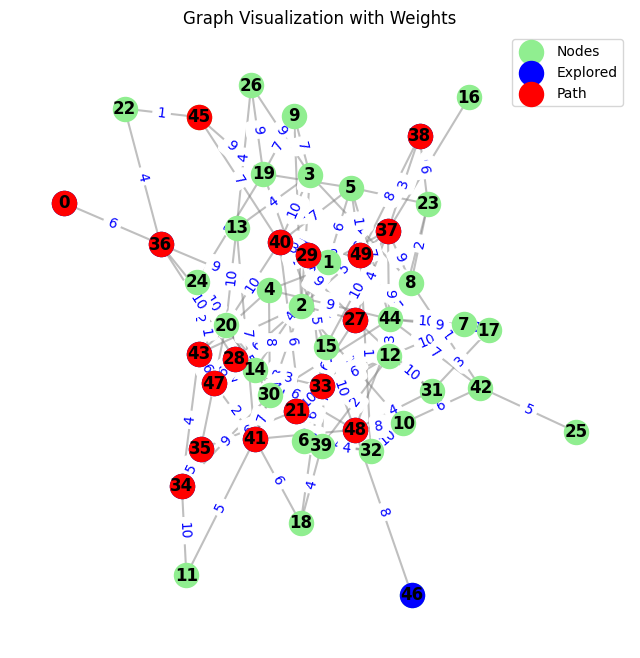

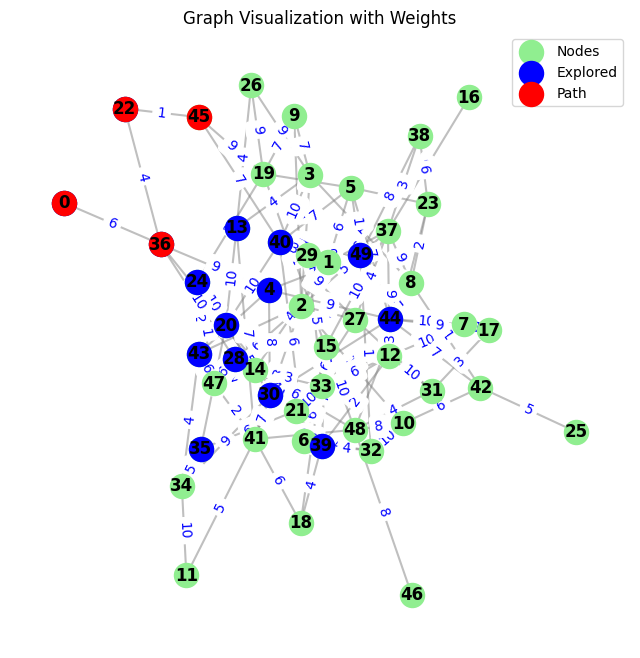

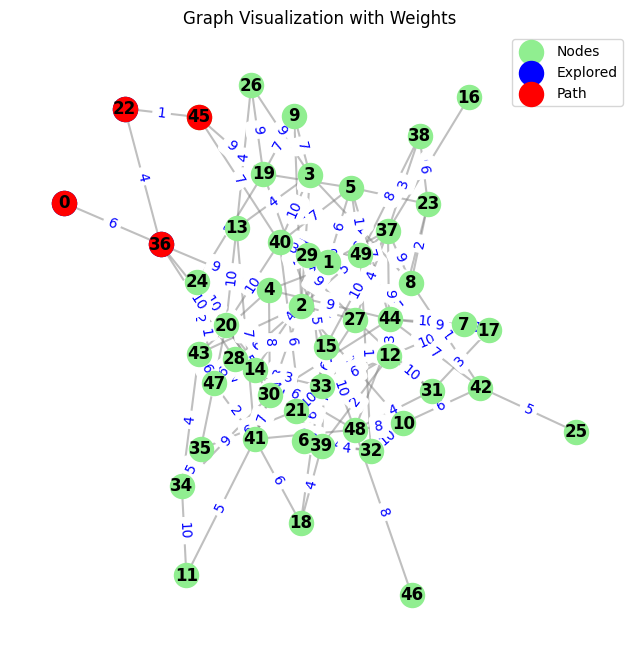

In [113]:
# Parameters
num_nodes = 50  # Number of nodes in the graph
start_node = 0  # Starting node
goal_node = 45   # Goal node

# Generate random weighted graph
weighted_graph = generate_weighted_graph(num_nodes)

# Run DFS
path_dfs, weight_dfs, explored_dfs = dfs_weighted(weighted_graph, start_node, goal_node)
print(f"DFS Path: {path_dfs}")
print(f"DFS Weight Sum: {weight_dfs}")

# Run BFS
path_bfs, weight_bfs, explored_bfs = bfs_weighted(weighted_graph, start_node, goal_node)
print(f"BFS Path: {path_bfs}")
print(f"BFS Weight Sum: {weight_bfs}")

# Run Dijkstra
path_dijkstra, weight_dijkstra, explored_dijkstra = dijkstra(weighted_graph, start_node, goal_node)
print(f"Dijkstra Path: {path_dijkstra}")
print(f"Dijkstra Weight Sum: {weight_dijkstra}")

# Visualize the results
plot_graph(weighted_graph, path=path_dfs, explored=explored_dfs)
plot_graph(weighted_graph, path=path_bfs, explored=explored_bfs)
plot_graph(weighted_graph, path=path_dijkstra, explored=explored_dijkstra)


**What are the key diffrences between dijkstra, bfs and dfs? Which one of them has acted better in our problem and why? What happens when graph is directed?**

Your Answer:

The Dijkstra algorithm, at each step, selects a node from the Fringe to expand that has the lowest g value and is implemented using a min-heap. It is applicable to weighted graphs (with non-negative weights).  
The BFS algorithm aims to find the shortest path (in terms of the number of edges) in an unweighted graph. At each step, it selects a node from the Fringe to expand that has the lowest height (distance in terms of the number of edges from the source node). It is implemented using a regular queue.  
The DFS algorithm uses a stack for implementation and, at each step, selects a node from the Fringe to expand that has the greatest height (distance in terms of the number of edges from the source node).  
Here, the graph is weighted, so Dijkstra performs the best because it takes edge weights into account when calculating g and determining the order of expansion, whereas BFS and DFS only consider the height of the nodes.  
We know that Dijkstra's algorithm is optimal and guarantees the selection of the least-cost path. However, when edge weights vary, BFS and DFS do not necessarily yield optimal solutions.  
In general, the directedness of the graph affects the performance of these algorithms, but their core principles remain unchanged. Care must be taken to ensure that paths are explored based on the direction of the edges.

# **Local Search**

# Problem definition
In this part, you should implement **Hill-Climbing** and **Genentic** algorithms. Afterwards you will test them on a formal np problem (Subset Sum)

Suppose we have a limit for our back pack that we show with *target_sum* and random number of materials with some rand weights which are present in *nums*. To do that we will implement 3 algorithms. First, you should implement  **Hill-Climbing**, and then you should implement the **Genetic Algorithm**. At last, you should find the actual answer using **Naive Search (brute force)**.

In [81]:
# Sample input for Subset Sum Problem
target_sum = 60
nums = [random.randint(1, 10) for _ in range(15)]  # Random list of 15 integers between 1 and 10

print(f"Numbers: {nums}")
print(f"Target Sum: {target_sum}")


Numbers: [4, 6, 1, 9, 6, 1, 4, 4, 9, 2, 10, 1, 6, 2, 4]
Target Sum: 60


# Hill Climbing

In order to implement hill climbing, you must at first define the neighbors in your model. We suggest that every addition or omition of your current bag should be a neighbor yet you can implement it how you want.

In [82]:
def count_elements(list):
    freq = {}
    for num in list:
        freq[num] = freq.get(num, 0) + 1
    return freq

def hill_climbing(nums, target_sum):
    #Random initial solution (subset of nums)
    current_solution = random.sample(nums, random.randint(1, len(nums)))
    current_sum = sum(current_solution)
    #TODO Hill climbing

    while True:
        neighbors = []
        nums_count = count_elements(nums)
        current_count = count_elements(current_solution)

        for number in nums:
            if  current_count.get(number, 0) < nums_count.get(number, 0):
                neighbors.append(current_solution + [number])

        for number in current_solution:
            neighbor = current_solution.copy()
            neighbor.remove(number)
            neighbors.append(neighbor)

        best_neighbor = current_solution
        best_sum = current_sum
        for neighbor in neighbors:
            if abs(sum(neighbor) - target_sum) < abs(best_sum - target_sum):
                best_neighbor = neighbor
                best_sum = sum(neighbor)
        
        if best_sum == current_sum:
            break
        else:
            current_solution = best_neighbor
            current_sum = best_sum
    

    #return a current solution = best state value
    #Hill climbing loop
    #Generate neighbors by adding one element or removing one element 
    #Evaluate the neighbors by calculating the sum
    #If no improvement, stop
    return current_solution

در پیاده سازی زیر فرض شده که استیت ها به صورت یک لیست باینری به طول لیست داده شده است . و 1 نشان دهنده این است که آن عضو از لیست آمده است .

In [ ]:
def hill_climbing1(nums, target_sum):
    def subset_sum(subset):
        sum = 0
        for i in range(len(subset)):
            if subset[i] == 1:
                sum += nums[i]
        return sum
    
    def subset_neighbors(subset):
        neighbors = []
        for i in range(len(subset)):
            neighbor = subset.copy()
            neighbor[i] = 1 if neighbor[i] == 0 else 0
            neighbors.append(neighbor)
        return neighbors

    current_solution = random.choices([0,1], k=len(nums))
    current_sum = subset_sum(current_solution)

    while True:
        neighbors = subset_neighbors(current_solution)
        best_neighbor = current_solution
        best_sum = current_sum

        for neighbor in neighbors:
            neighbor_sum = subset_sum(neighbor)
            if abs(neighbor_sum - target_sum) < abs(best_sum - target_sum):
                best_neighbor = neighbor
                best_sum = neighbor_sum
        
        if best_sum == current_sum:
            break
        else:
            current_solution = best_neighbor
            current_sum = best_sum
    
    return [nums[i] for i in range(len(current_solution)) if current_solution[i] == 1]

# Genetic Algorithm
As you have learned, in order to implement GA, you need to define mutation function and crossover functions(single pointed one would be enough).

Then, in main GA body, a population of random solutions (subsets) is created. These solutions evolve over a number of generations through selection, crossover, and mutation.
The algorithm aims to evolve the population towards finding a subset whose sum is as close as possible to the target sum. After a set number of generations, the algorithm returns the best solution found.

در پیاده سازی زیر فرض شده که استیت ها به صورت یک لیست باینری به طول لیست داده شده است . و 1 نشان دهنده این است که آن عضو از لیست آمده است .

In [84]:
def tournament_selection(population, target_sum, nums, tournament_size=5):
    def subset_sum(subset):
        return sum(nums[i] for i in range(len(subset)) if subset[i] == 1)
    tournament = random.sample(population, tournament_size)
    tournament.sort(key=lambda x: abs(target_sum - subset_sum(x)))
    return tournament[0]  # Best solution in the tournament

def crossover(parent1, parent2):
    # Single-point crossover
    #TODO randomly choose one point and do crossover on that
    point = random.randint(1, min(len(parent1), len(parent2)) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2
    #return childs created of process (child1 and child 2)
    
def mutate(solution, nums, mutation_rate=0.1):
    #TODO
    if random.random() < mutation_rate: 
        i = random.choice(solution)
        solution[i] = 1 - solution[i]
    # Mutate the solution by either adding a random number from nums that isn't in solution or removing a random number from solution 
    #chanced are based on mutation_rate (when your chance is less that rate it will happen)
    #return the mutated solution.
    return solution

In [85]:
def genetic_algorithm(nums, target_sum, population_size=50, generations=100, mutation_rate=0.1):
    def subset_sum(subset):
        sum = 0
        for i in range(len(subset)):
            if subset[i] == 1:
                sum += nums[i]
        return sum
    
    # Random initial population
    population = [random.choices([0,1], k=len(nums)) for _ in range(population_size)]

    #TODO perform Genetic algorithm
    for _ in range(generations):
        population.sort(key=lambda x: abs(target_sum - subset_sum(x)))
        
        if subset_sum(population[0]) == target_sum:
            return [nums[i] for i in range(len(population[0])) if population[0][i] == 1]
        
        new_population = []

        while len(new_population) < population_size :
            parent1 = tournament_selection(population, target_sum, nums)
            parent2 = tournament_selection(population, target_sum, nums)
            
            child1, child2 = crossover(parent1, parent2)
            
            child1 = mutate(child1, nums, mutation_rate)
            child2 = mutate(child2, nums, mutation_rate)
            
            new_population.append(child1)
            
            if len(new_population) < population_size:
                new_population.append(child2)
                

        population = new_population[:population_size]
    
    population.sort(key=lambda x: abs(target_sum - subset_sum(x)))
    # Sort the population by fitness and select the best solution; if it matches the target, return it.
    # Use tournament selection, crossover, and mutation to create the next generation until the population size is met.
    # Return the best solution after all generations
    return [nums[i] for i in range(len(population[0])) if population[0][i] == 1]

# Brute Force

In [86]:
def brute_force(nums, target_sum):
    #TODO check all possible combinations and return the best subset
    best_combination = []
    best_sum = 0

    for i in range(1, len(nums) + 1): 
        for combination in combinations(nums, i):
            combination_sum = sum(combination)
            if abs(combination_sum - target_sum )< abs(best_sum - target_sum):
                best_combination = combination
                best_sum = combination_sum
                if best_sum == target_sum:
                    break
    
    return list(best_combination)


# Comparison

Run the 3 algorithms 10 times and watch the result. Hill climbing and Genetic Algorithm results should be close to actual answers(brute force results).


In [122]:
# Running the algorithms multiple times with different random setups
def run_multiple_trials(num_trials=10):
    hill_climbing_times = []
    ga_times = []
    brute_force_times = []

    hill_climbing_solutions = []
    ga_solutions = []
    brute_force_solutions = []

    for i in range(num_trials):
        # Generate random setup for each trial
        target_sum = random.randint(50, 100)  # Random target sum between 10 and 50
        nums = [random.randint(1, 10) for _ in range(random.randint(10, 30))]  # Random list size between 10 and 20
        hill_climb_sum = 0
        genetic_sum = 0
        brute_force_sum = 0
        # Print the current trial setup
        print(f"Trial {i + 1}: Target Sum = {target_sum}, Numbers = {nums}")

        # Hill Climbing
        start_time = time.time()
        hill_climb_result = hill_climbing(nums, target_sum)
        hill_climb_time = time.time() - start_time
        hill_climbing_times.append(hill_climb_time)
        hill_climbing_solutions.append(hill_climb_result)
        hill_climb_sum = sum(hill_climb_result)

        # Genetic Algorithm
        start_time = time.time()
        ga_result = genetic_algorithm(nums, target_sum)
        ga_time = time.time() - start_time
        ga_times.append(ga_time)
        ga_solutions.append(ga_result)
        genetic_sum = sum(ga_result)

        # Brute Force
        start_time = time.time()
        brute_force_result = brute_force(nums, target_sum)
        brute_force_time = time.time() - start_time
        brute_force_times.append(brute_force_time)
        brute_force_solutions.append(brute_force_result)
        brute_force_sum = sum(brute_force_result) if brute_force_result else 0

        # Print each trial result
        print(f"Hill Climbing Result: {hill_climb_result}, final sum: {hill_climb_sum}, Time Taken: {hill_climb_time:.4f} seconds")
        print(f"Genetic Algorithm Result: {ga_result}, final sum: {genetic_sum}, Time Taken: {ga_time:.4f} seconds")
        print(f"Brute Force Result: {brute_force_result}, final sum: {brute_force_sum}, Time Taken: {brute_force_time:.4f} seconds\n")

    # Calculate average times
    avg_hill_climbing_time = sum(hill_climbing_times) / num_trials
    avg_ga_time = sum(ga_times) / num_trials
    avg_brute_force_time = sum(brute_force_times) / num_trials

    print("\nAverage Times over 10 Trials:")
    print(f"Hill Climbing Average Time: {avg_hill_climbing_time:.4f} seconds")
    print(f"Genetic Algorithm Average Time: {avg_ga_time:.4f} seconds")
    print(f"Brute Force Average Time: {avg_brute_force_time:.4f} seconds")

# Run the comparison with 10 trials
run_multiple_trials(num_trials=10)


Trial 1: Target Sum = 89, Numbers = [4, 8, 4, 9, 9, 1, 9, 10, 1, 2, 1, 5, 1, 1, 3, 9, 3, 9, 8, 5]
Hill Climbing Result: [1, 5, 1, 1, 9, 9, 8, 9, 9, 8, 4, 9, 10, 5, 1], final sum: 89, Time Taken: 0.0000 seconds
Genetic Algorithm Result: [4, 8, 4, 9, 9, 1, 9, 10, 1, 5, 1, 3, 9, 3, 8, 5], final sum: 89, Time Taken: 0.0012 seconds
Brute Force Result: [4, 8, 4, 9, 9, 9, 10, 5, 9, 9, 8, 5], final sum: 89, Time Taken: 0.1202 seconds

Trial 2: Target Sum = 93, Numbers = [7, 3, 5, 4, 10, 4, 1, 7, 10, 6, 1, 9, 7, 1, 2, 3, 8, 8, 3, 9, 2, 10, 7, 10, 10, 9, 8, 9, 7]
Hill Climbing Result: [5, 1, 9, 9, 2, 1, 7, 7, 4, 3, 2, 8, 1, 9, 8, 6, 4, 7], final sum: 93, Time Taken: 0.0001 seconds
Genetic Algorithm Result: [3, 1, 7, 6, 1, 9, 2, 3, 8, 9, 10, 7, 10, 10, 7], final sum: 93, Time Taken: 0.0001 seconds
Brute Force Result: [7, 10, 10, 9, 9, 10, 10, 10, 9, 9], final sum: 93, Time Taken: 161.2160 seconds

Trial 3: Target Sum = 93, Numbers = [5, 4, 6, 7, 2, 1, 7, 4, 6, 9, 10, 10, 1, 2, 8, 2, 9, 7, 2]
Hill

**Now Compare and contrast the performance of brute-force search, hill climbing, and genetic algorithms in Problems. Discuss the strengths and weaknesses of each approach in this context, and explain when each algorithm might be preferred over the others.**


Your Answer : The Brute force algorithm examines all possible states and, if an optimal solution exists, it finds it. However, in large and complex problems, due to the exponential increase in possible states, it becomes impractical and consumes a significant amount of time and memory. Consequently, it is suitable for small and constrained problems where guaranteeing the discovery of the optimal solution is essential.

The Hill Climbing algorithm typically reaches a good solution quickly (although it may be only a local optimum). It can get stuck in a local peak and fail to find the global optimum, and the final result is highly dependent on the initial state chosen. Therefore, in situations where the speed of finding a solution is important—even if it might get trapped in local optima and an exact solution is less critical (with approximate solutions being acceptable)—this approach is preferred.

On the other hand, Genetic Algorithms have the ability to escape local optima, but they depend on parameters such as population size, mutation rate, and crossover rate, and they require more time than Hill Climbing. They are particularly applicable to asymmetric and intricate search spaces.